In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd

from src.steer_vec_loader import SteerVecLoader
from src.gram_matrix import compute_gram_matrix
from src.pair_strat import get_offdiag, make_pairs_df, stratify_pairs
from src.eda import run_eda

In [2]:
LAYER = 17
PATH = f"/Users/federicoscaffidimuta/Desktop/Third year/ML project/steering-vector-composition/results/layer_{LAYER}_vectors"

loader = SteerVecLoader(steer_vec_path=PATH, layer=LAYER)
loader.load_steer_vecs()
behavior_vecs, behaviors = loader.to_matrix()

In [3]:
behavior_matrix = behavior_vecs.shape
print(f"Behavior matrix shape: {behavior_matrix}")

vec_shape = behavior_vecs.shape[0]
print(f"Number of vectors is N = {vec_shape}")

expected_shape = (7, 4096)

G = compute_gram_matrix(behavior_vecs, expected_shape)  # compute gram matrix
print(f"Gram matrix shape is {G.shape}")

Behavior matrix shape: (7, 4096)
Number of vectors is N = 7
Gram matrix shape is (7, 7)


In [4]:
pairs_df = make_pairs_df(G, behaviors)  # get pairs dataframe
pairs_df.head(n=40)

,i,j,behavior_i,behavior_j,cosine,abs_cosine
0,0,1,hallucination,myopia,-0.128382,0.128382
1,0,2,hallucination,verbosity,-0.000069,0.000069
2,0,3,hallucination,formality,0.043726,0.043726
3,0,4,hallucination,politeness,-0.068265,0.068265
4,0,5,hallucination,confidence,0.221910,0.221910
5,0,6,hallucination,agreeableness,-0.106368,0.106368
6,1,2,myopia,verbosity,0.053411,0.053411
7,1,3,myopia,formality,-0.083584,0.083584
8,1,4,myopia,politeness,-0.028038,0.028038
9,1,5,myopia,confidence,-0.006879,0.006879


In [5]:
strat_df = stratify_pairs(pairs_df)
strat_df.head(n=40)

[WARN] stratum 'moderate' has 5 pairs, wanted 13
[WARN] stratum 'high' has 0 pairs, wanted 13


,i,j,behavior_i,behavior_j,cosine,abs_cosine,stratum
0,0,1,hallucination,myopia,-0.128382,0.128382,near
1,0,2,hallucination,verbosity,-0.000069,0.000069,near
2,1,2,myopia,verbosity,0.053411,0.053411,near
3,4,6,politeness,agreeableness,0.145456,0.145456,near
4,3,4,formality,politeness,0.018243,0.018243,near
5,2,5,verbosity,confidence,0.063295,0.063295,near
6,1,5,myopia,confidence,-0.006879,0.006879,near
7,2,3,verbosity,formality,0.046438,0.046438,near
8,0,3,hallucination,formality,0.043726,0.043726,near
9,5,6,confidence,agreeableness,-0.075361,0.075361,near


=== Summary statistics (all pairs) ===
                        value
n_pairs             21.000000
mean                 0.009813
std                  0.124908
min                 -0.271593
max                  0.221910
mean_abs             0.098166
std_abs              0.074731
near (<0.2)         19.000000
moderate [0.2,0.5)   2.000000
high (>=0.5)         0.000000

=== Most similar pairs ===
   behavior_i    behavior_j    cosine  abs_cosine
   politeness    confidence -0.271593    0.271593
hallucination    confidence  0.221910    0.221910
    formality    confidence  0.194718    0.194718
       myopia agreeableness  0.191925    0.191925
    formality agreeableness -0.159166    0.159166

=== Most orthogonal pairs ===
   behavior_i behavior_j    cosine  abs_cosine
hallucination  verbosity -0.000069    0.000069
       myopia confidence -0.006879    0.006879
    formality politeness  0.018243    0.018243
       myopia politeness -0.028038    0.028038
hallucination  formality  0.043726   

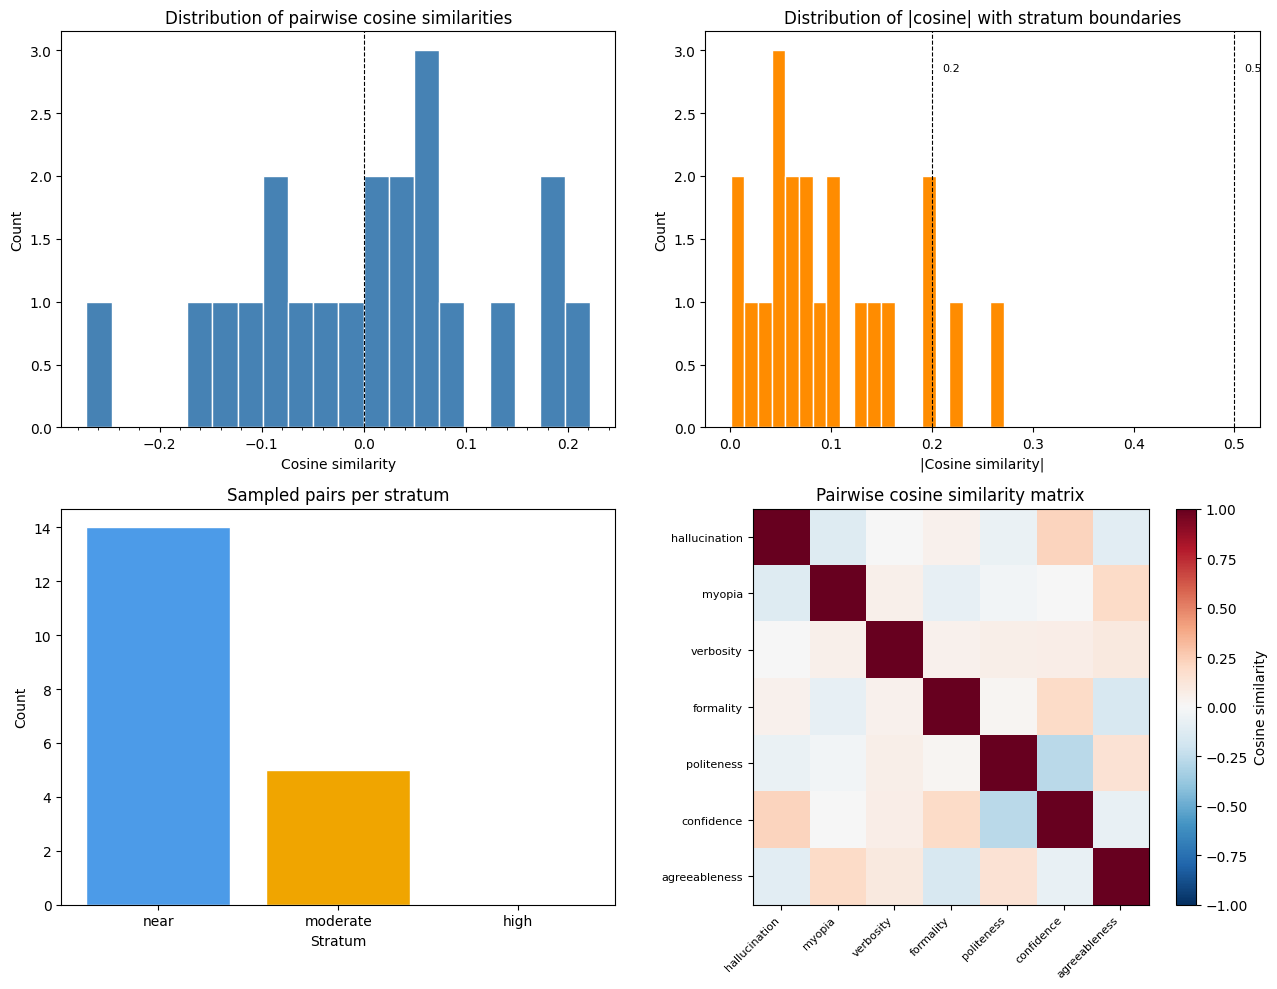

In [6]:
run_eda(pairs_df=pairs_df, strat_df=strat_df, behaviors=behaviors)